# Task 9 — Feature Engineering
## Step 4: Feature Scaling

**Goal:** Bring all numerical features onto a comparable scale so that
distance-based or gradient-based algorithms are not biased by
features with larger ranges.

| Scaler | Formula | Best for |
|--------|---------|----------|
| StandardScaler | (x − mean) / std | Normally distributed data, SVM, Logistic Regression |
| MinMaxScaler | (x − min) / (max − min) | Bounded range needed, KNN, Neural Networks |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/cleaned_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1309, 8)


,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


### 4.1 Identify Columns to Scale

Only continuous numerical columns are scaled.  
Binary and dummy columns (0/1) are left as-is.

In [3]:
# Columns to scale: continuous numeric only
scale_cols = ['Age', 'Fare']
# Columns to leave: binary / dummy / target
skip_cols = [col for col in df.columns if col not in scale_cols]
print(f'Columns to scale:  {scale_cols}')
print(f'Columns untouched: {skip_cols}')
print(f'\nBefore scaling:')
df[scale_cols].describe().T

Columns to scale:  ['Age', 'Fare']
Columns untouched: ['Sex', 'sibsp', 'Parch', 'Pclass', 'Embarked', 'Survived']

Before scaling:


,count,mean,std,min,25%,50%,75%,max
Age,1309.0,29.503186,12.905241,0.17,22.0000,28.0000,35.000,80.0000
Fare,1309.0,33.281086,51.741500,0.00,7.8958,14.4542,31.275,512.3292


### 4.2 Visualize Distributions Before Scaling

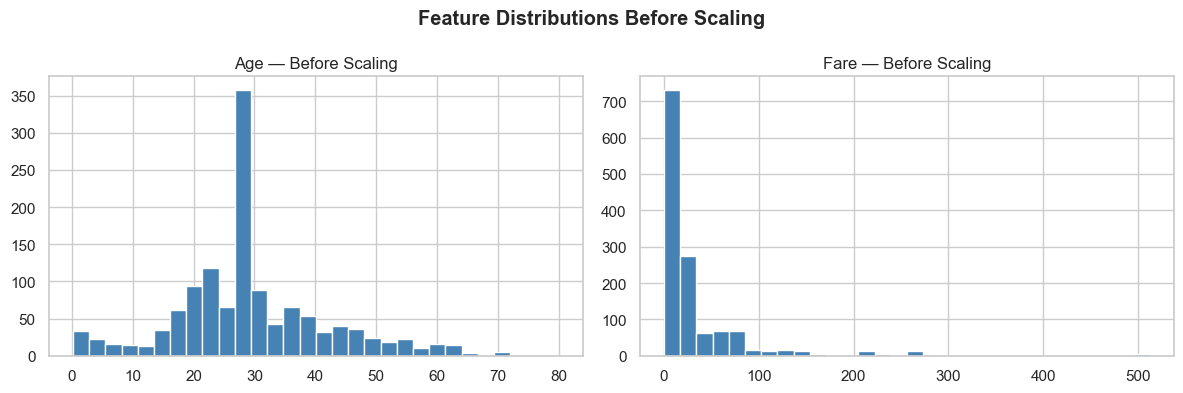

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(scale_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} — Before Scaling')
plt.suptitle('Feature Distributions Before Scaling', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Apply StandardScaler

Transforms features to have **mean = 0** and **standard deviation = 1**.  
This is the most widely used scaler for ML algorithms.

In [6]:
df_standard = df.copy()
scaler_std = StandardScaler()
df_standard[scale_cols] = scaler_std.fit_transform(df[scale_cols])

print('After StandardScaler:')
print(df_standard[scale_cols].describe().T[['mean', 'std', 'min', 'max']].round(4))

After StandardScaler:
      mean     std     min     max
Age    0.0  1.0004 -2.2738  3.9144
Fare  -0.0  1.0004 -0.6435  9.2620


### 4.4 Apply MinMaxScaler

Scales features to a fixed range of **[0, 1]**.  
Useful when a bounded range is required.

In [7]:
df_minmax = df.copy()
scaler_mm = MinMaxScaler()
df_minmax[scale_cols] = scaler_mm.fit_transform(df[scale_cols])

print('After MinMaxScaler:')
print(df_minmax[scale_cols].describe().T[['mean', 'std', 'min', 'max']].round(4))

After MinMaxScaler:
        mean     std  min  max
Age   0.3674  0.1617  0.0  1.0
Fare  0.0650  0.1010  0.0  1.0


### 4.5 Visual Comparison — Before vs StandardScaler vs MinMaxScaler

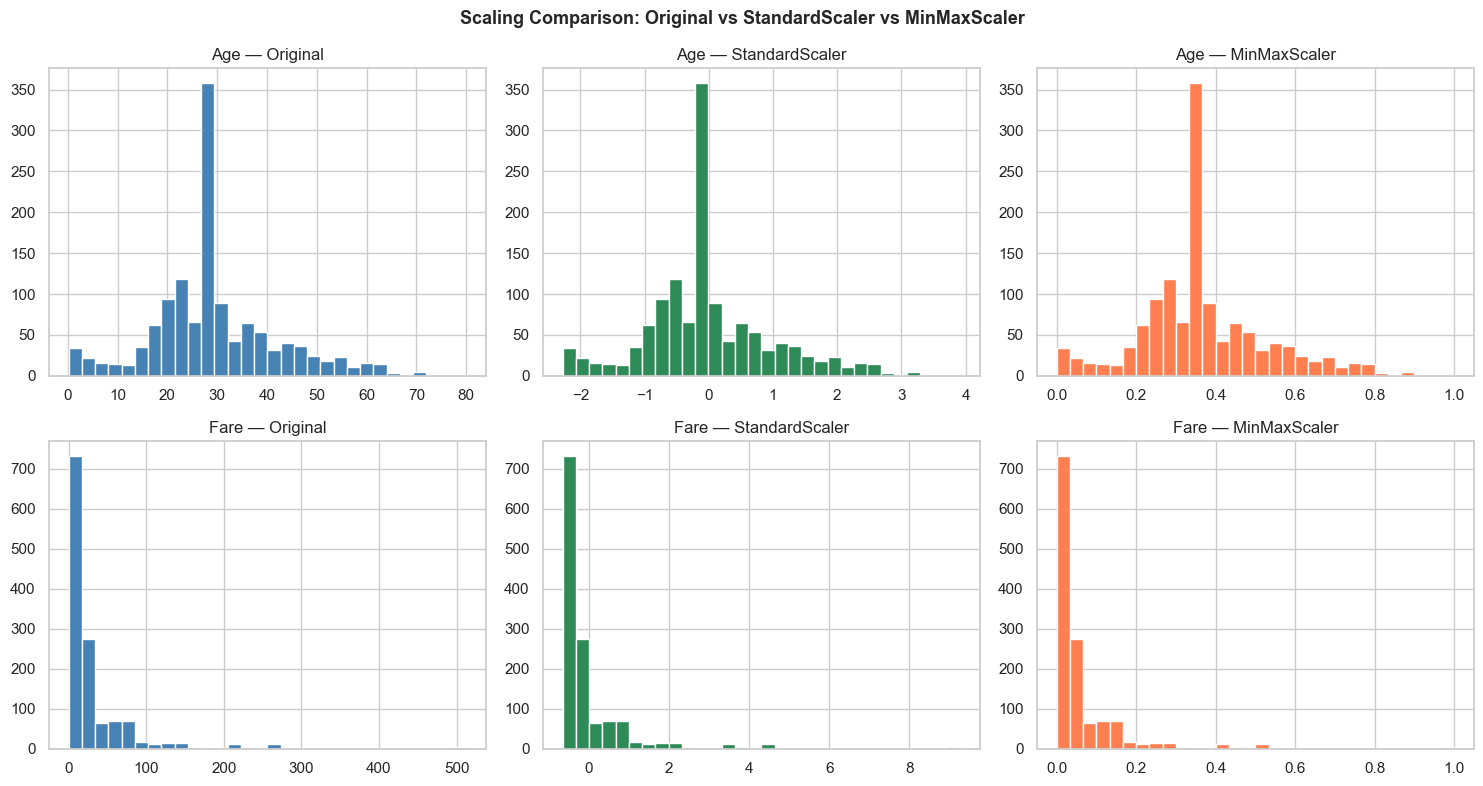

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['steelblue', 'seagreen', 'coral']
labels = ['Original', 'StandardScaler', 'MinMaxScaler']
datasets = [df, df_standard, df_minmax]

for row, col in enumerate(scale_cols):
    for c, (data, label, color) in enumerate(zip(datasets, labels, colors)):
        axes[row][c].hist(data[col], bins=30, color=color, edgecolor='white')
        axes[row][c].set_title(f'{col} — {label}')

plt.suptitle('Scaling Comparison: Original vs StandardScaler vs MinMaxScaler',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()